In [ ]:
import sys

print("Python:", sys.version)
print("Executable:", sys.executable)

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
Executable: /usr/bin/python3


In [ ]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!rm -rf /content/drive

In [ ]:
from google.colab import drive

drive.mount("/content/drive", force_remount= True )

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import tensorflow as tf

from tensorflow.keras import layers, models

print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

NumPy: 2.1.3
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
BASE_PATH = "/content/drive/MyDrive/SIH2026"

PROCESSED_PATH = os.path.join(BASE_PATH, "Processed")

print(PROCESSED_PATH)
print(os.listdir(PROCESSED_PATH))

/content/drive/MyDrive/SIH2026/Processed
['Final_X_JanFebMar.npy', 'Final_Y_JanFebMar.npy']


In [ ]:
import numpy as np
import os

X_jan = np.load(
    "/content/drive/MyDrive/SIH2026/Processed/X_Jan2020.npy"
)

Y_jan = np.load(
    "/content/drive/MyDrive/SIH2026/Processed/Y_Jan2020.npy"
)

print("January X:", X_jan.shape)
print("January Y:", Y_jan.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/SIH2026/Processed/X_Jan2020.npy'

In [ ]:
# January currently:
# X = (180, 360, 4)
# Channels = [SST, SSH, U10, V10]

# Keep only SST + SSH
X_jan_2ch = X_jan[:, :, :2]

# January Y:
# (23, 180, 360)
# Convert to:
# (180, 360, 23)

Y_jan_23 = np.transpose(Y_jan, (1, 2, 0))

print("January X:", X_jan_2ch.shape)
print("January Y:", Y_jan_23.shape)

In [ ]:
X_feb = np.load(
    "/content/drive/MyDrive/SIH2026/Processed/X_202002.npy"
)

Y_feb = np.load(
    "/content/drive/MyDrive/SIH2026/Processed/Y_202002.npy"
)

X_mar = np.load(
    "/content/drive/MyDrive/SIH2026/Processed/X_202003.npy"
)

Y_mar = np.load(
    "/content/drive/MyDrive/SIH2026/Processed/Y_202003.npy"
)

print("February X:", X_feb.shape)
print("February Y:", Y_feb.shape)

print("March X:", X_mar.shape)
print("March Y:", Y_mar.shape)

In [ ]:
# Combine the 3 months along the time dimension

X_sequence = np.stack(
    [
        X_jan_2ch,
        X_feb,
        X_mar
    ],
    axis=0
)

# Add batch dimension
X_sequence = np.expand_dims(
    X_sequence,
    axis=0
)

# March is our prediction target
Y_sequence = np.expand_dims(
    Y_mar,
    axis=0
)

print("X sequence:", X_sequence.shape)
print("Y sequence:", Y_sequence.shape)

In [ ]:
import os
import numpy as np

FINAL_PATH = "/content/drive/MyDrive/SIH2026/Processed"

# Save X
X_final_path = os.path.join(
    FINAL_PATH,
    "Final_X_JanFebMar.npy"
)

np.save(
    X_final_path,
    X_sequence.astype(np.float32)
)

# Save Y
Y_final_path = os.path.join(
    FINAL_PATH,
    "Final_Y_JanFebMar.npy"
)

np.save(
    Y_final_path,
    Y_sequence.astype(np.float32)
)

print("X saved:")
print(X_final_path)

print("\nY saved:")
print(Y_final_path)

In [22]:
# ============================================================
# LOAD FINAL 3-MONTH DATASET
# ============================================================

import os
import numpy as np

FINAL_PATH = "/content/drive/MyDrive/SIH2026/Processed"

# Load final input data
X = np.load(
    os.path.join(
        FINAL_PATH,
        "Final_X_JanFebMar.npy"
    )
)

# Load final target data
Y = np.load(
    os.path.join(
        FINAL_PATH,
        "Final_Y_JanFebMar.npy"
    )
)

print("X loaded successfully")
print("Y loaded successfully")

print("\nX shape:", X.shape)
print("Y shape:", Y.shape)

print("\nX dtype:", X.dtype)
print("Y dtype:", Y.dtype)

print("\nX NaNs:", np.isnan(X).sum())
print("Y NaNs:", np.isnan(Y).sum())

X loaded successfully
Y loaded successfully

X shape: (1, 3, 180, 360, 2)
Y shape: (1, 180, 360, 23)

X dtype: float32
Y dtype: float32

X NaNs: 153168
Y NaNs: 814039


In [23]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [24]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [25]:
import numpy as np
import os

BASE_PATH = "/content/drive/MyDrive/SIH2026"
PROCESSED_PATH = os.path.join(BASE_PATH, "Processed")

X = np.load(
    os.path.join(
        PROCESSED_PATH,
        "Final_X_JanFebMar.npy"
    )
)

Y = np.load(
    os.path.join(
        PROCESSED_PATH,
        "Final_Y_JanFebMar.npy"
    )
)

print("X:", X.shape, X.dtype)
print("Y:", Y.shape, Y.dtype)

print("X NaNs:", np.isnan(X).sum())
print("Y NaNs:", np.isnan(Y).sum())

X: (1, 3, 180, 360, 2) float32
Y: (1, 180, 360, 23) float32
X NaNs: 153168
Y NaNs: 814039


In [26]:
# We use the mask so the model is not penalized at locations where Argo has no ground-truth observation.
Y_mask = np.isfinite(Y).astype(np.float32)

print("Mask:", Y_mask.shape)
print("Valid:", int(Y_mask.sum()))
print("Missing:", int((Y_mask == 0).sum()))

Mask: (1, 180, 360, 23)
Valid: 676361
Missing: 814039


In [27]:
# in the nan value replce the number with means of the sample dude

X_model = X.copy()

for c in range(X_model.shape[-1]):

    mean_value = np.nanmean(
        X_model[:, :, :, :, c]
    )

    print(
        f"Channel {c} mean: {mean_value:.6f}"
    )

    X_model[:, :, :, :, c] = np.where(
        np.isnan(X_model[:, :, :, :, c]),
        mean_value,
        X_model[:, :, :, :, c]
    )

print(
    "Remaining X NaNs:",
    np.isnan(X_model).sum()
)

Channel 0 mean: 14.087050
Channel 1 mean: 0.081010
Remaining X NaNs: 0


In [28]:
# normalize the  sst and ssh
X_norm = X_model.copy()

input_means = []
input_stds = []

for c in range(X_norm.shape[-1]):

    # Calculate statistics for this channel
    mean = np.mean(X_norm[:, :, :, :, c])
    std = np.std(X_norm[:, :, :, :, c])

    input_means.append(mean)
    input_stds.append(std)

    # Standardization
    X_norm[:, :, :, :, c] = (
        X_norm[:, :, :, :, c] - mean
    ) / (std + 1e-8)

    print(
        f"Channel {c}: "
        f"mean={mean:.6f}, "
        f"std={std:.6f}"
    )

print("\nX shape:", X_norm.shape)
print("Remaining NaNs:", np.isnan(X_norm).sum())

Channel 0: mean=14.087051, std=9.443686
Channel 1: mean=0.081010, std=0.069063

X shape: (1, 3, 180, 360, 2)
Remaining NaNs: 0


In [29]:
# converting the nan vlaue to 0 but it does not consider with 0 value
Y_model = np.nan_to_num(
    Y,
    nan=0.0
).astype(np.float32)

print("Y shape:", Y_model.shape)
print("Y NaNs:", np.isnan(Y_model).sum())

Y shape: (1, 180, 360, 23)
Y NaNs: 0


In [30]:
# converting to tensor
X_train = tf.convert_to_tensor(
    X_norm,
    dtype=tf.float32
)

Y_train = tf.convert_to_tensor(
    Y_model,
    dtype=tf.float32
)

Y_mask_tf = tf.convert_to_tensor(
    Y_mask,
    dtype=tf.float32
)

print("X:", X_train.shape)
print("Y:", Y_train.shape)
print("Mask:", Y_mask_tf.shape)

X: (1, 3, 180, 360, 2)
Y: (1, 180, 360, 23)
Mask: (1, 180, 360, 23)


In [32]:
# BUILD CONVLSTM MODEL
# input 3 month 180 latitiude and 360 longitude points   2 features sst and ssh

# Shape:
#   (3, 180, 360, 2)

# Output:  23 surphase temprature

# Shape:   (180, 360, 23)


from tensorflow.keras import layers, models

inputs = layers.Input(
    shape=(3, 180, 360, 2),
    name="surface_input"
)


# First ConvLSTM layer

# Learns spatial + temporal patterns while keeping
# the complete 3-month sequence.


x = layers.ConvLSTM2D(
    filters=8,
    kernel_size=(3, 3),
    padding="same",
    return_sequences=True,
    activation="tanh",
    name="convlstm_1"
)(inputs)

x = layers.BatchNormalization(
    name="batch_norm_1"
)(x)


# Second ConvLSTM layer

# Processes the temporal features learned by the first
# ConvLSTM layer.
#
# return_sequences=False means that after processing the
# January → February → March sequence, we keep the final
# spatial representation.


x = layers.ConvLSTM2D(
    filters=16,
    kernel_size=(3, 3),
    padding="same",
    return_sequences=False,
    activation="tanh",
    name="convlstm_2"
)(x)

x = layers.BatchNormalization(
    name="batch_norm_2"
)(x)


# Spatial convolution


x = layers.Conv2D(
    filters=16,
    kernel_size=(3, 3),
    padding="same",
    activation="relu",
    name="spatial_conv"
)(x)


# Output layer

# 23 filters = 23 depth levels


outputs = layers.Conv2D(
    filters=23,
    kernel_size=(1, 1),
    padding="same",
    activation="linear",
    name="temperature_output"
)(x)

model = models.Model(
    inputs=inputs,
    outputs=outputs
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ surface_input (InputLayer)      │ (None, 3, 180, 360, 2) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convlstm_1 (ConvLSTM2D)         │ (None, 3, 180, 360, 8) │         2,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 3, 180, 360, 8) │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convlstm_2 (ConvLSTM2D)         │ (None, 180, 360, 16)   │        13,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 180, 360, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_conv (Conv2D)           │ (None, 180, 360, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temperature_output (Conv2D)     │ (None, 180, 360, 23)   │           391 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,607 (76.59 KB)

 Trainable params: 19,559 (76.40 KB)

 Non-trainable params: 48 (192.00 B)

In [33]:
# Before training, we were doing a forward-pass test.
#Its purpose was simple: check whether the model can actually process your data without breaking.

prediction_test = model(
    X_train,
    training=False
)

print("Prediction shape:", prediction_test.shape)

print(
    "Prediction contains NaN:",
    tf.reduce_any(
        tf.math.is_nan(prediction_test)
    ).numpy()
)

Prediction shape: (1, 180, 360, 23)
Prediction contains NaN: False


In [34]:

Y_mask_tf = tf.constant(
    Y_mask,
    dtype=tf.float32
)


def masked_mse(y_true, y_pred):

    # Calculate squared prediction error
    squared_error = tf.square(
        y_true - y_pred
    )

    # Ignore locations where Argo is missing
    masked_error = (
        squared_error * Y_mask_tf
    )

    # Average only over valid Argo observations
    return (
        tf.reduce_sum(masked_error)
        /
        (tf.reduce_sum(Y_mask_tf) + 1e-8)
    )


print("Masked MSE defined successfully.")

Masked MSE defined successfully.


In [35]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=masked_mse
)

print("Model compiled successfully.")

Model compiled successfully.


In [36]:
# first convLSTM training
history = model.fit(
    X_train,
    Y_train,
    epochs=10,
    batch_size=1,
    verbose=1
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - loss: 121.6962
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 120.6210
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 119.7080
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 118.7550
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 117.7421
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 116.7011
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 115.6258
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 114.5125
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 113.3709
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 112.2088


In [37]:
# GENERATE FINAL PREDICTION

prediction = model.predict(
    X_train,
    batch_size=1,
    verbose=1
)

print("Prediction shape:", prediction.shape)

print("Prediction min :", np.min(prediction))
print("Prediction max :", np.max(prediction))
print("Prediction mean:", np.mean(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction shape: (1, 180, 360, 23)
Prediction min : -0.15282868
Prediction max : 0.45629475
Prediction mean: 0.023527032


In [38]:
# ============================================================
# EVALUATE PREDICTION AGAINST VALID ARGO OBSERVATIONS
# ============================================================
#
# We calculate error ONLY where:
#
#     Y_mask = 1
#
# Missing Argo locations are ignored.
# ============================================================

y_true = Y[0]
y_pred = prediction[0]
mask = Y_mask[0]

# Select only valid Argo observations
valid = mask == 1

true_valid = y_true[valid]
pred_valid = y_pred[valid]

# Calculate errors
errors = pred_valid - true_valid

mae = np.mean(np.abs(errors))
rmse = np.sqrt(np.mean(errors ** 2))

print("Valid observations:", len(true_valid))
print("MAE :", mae, "°C")
print("RMSE:", rmse, "°C")

Valid observations: 676361
MAE : 8.342695 °C
RMSE: 10.927388 °C


In [39]:
print("Actual Argo:")
print("Min :", np.min(true_valid))
print("Max :", np.max(true_valid))
print("Mean:", np.mean(true_valid))

print("\nPrediction:")
print("Min :", np.min(pred_valid))
print("Max :", np.max(pred_valid))
print("Mean:", np.mean(pred_valid))

Actual Argo:
Min : -1.903
Max : 30.201
Mean: 8.373384

Prediction:
Min : -0.13556057
Max : 0.45629475
Mean: 0.03645688


In [40]:
MODEL_PATH = "/content/drive/MyDrive/SIH2026/Models"

import os
os.makedirs(MODEL_PATH, exist_ok=True)

model.save(
    os.path.join(
        MODEL_PATH,
        "ConvLSTM_JanFebMar_Prototype.keras"
    )
)

print("Prototype model saved successfully.")

Prototype model saved successfully.


In [41]:
# SAVE PROTOTYPE PREDICTION

prediction_path = os.path.join(
    FINAL_PATH,
    "Prediction_JanFebMar_Prototype.npy"
)

np.save(
    prediction_path,
    prediction.astype(np.float32)
)


print("Prediction saved successfully.")
print(prediction_path)
print("Shape:", prediction.shape)

Prediction saved successfully.
/content/drive/MyDrive/SIH2026/Processed/Prediction_JanFebMar_Prototype.npy
Shape: (1, 180, 360, 23)


March SST
Min: -1.7999998
Max: 31.51
NaNs: 22410

March SSH
Min: -1.2785
Max: 0.97355
NaNs: 28682

March Argo 100m
Min: -1.828
Max: 29.327
NaNs: 35393


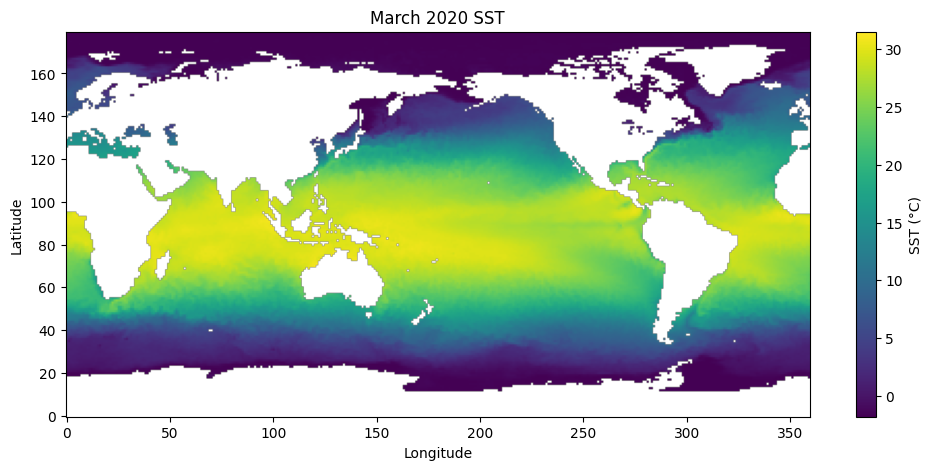

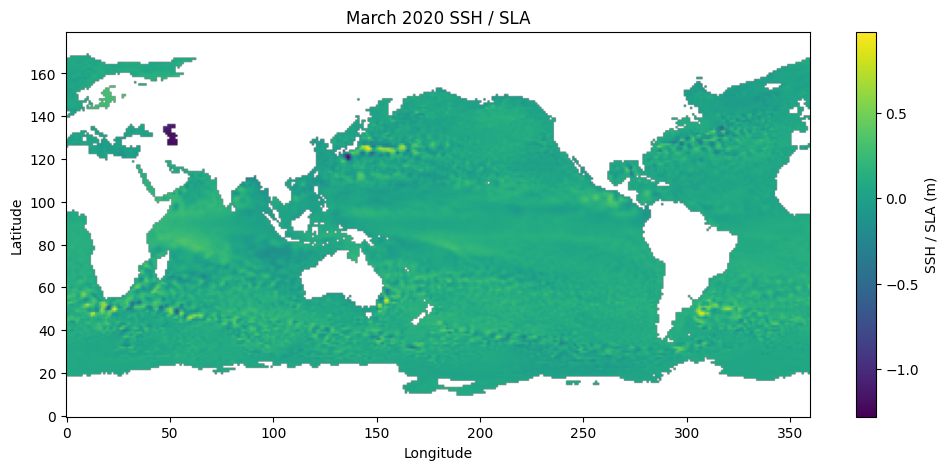

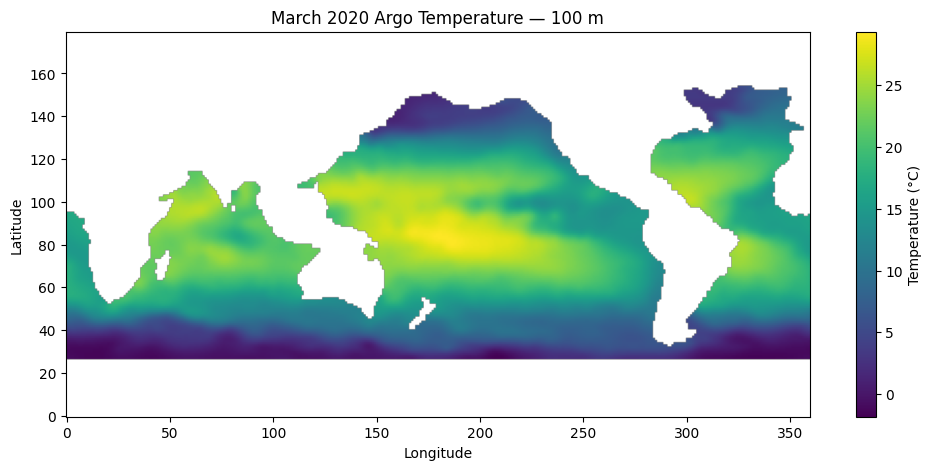

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LOAD FINAL DATA
# ============================================================

X = np.load(
    "/content/drive/MyDrive/SIH2026/Processed/Final_X_JanFebMar.npy"
)

Y = np.load(
    "/content/drive/MyDrive/SIH2026/Processed/Final_Y_JanFebMar.npy"
)

# ============================================================
# SELECT MARCH
# ============================================================

# X shape:
# (1, 3, 180, 360, 2)
#
# 0 = January
# 1 = February
# 2 = March
#
# Channel:
# 0 = SST
# 1 = SSH/SLA

march_sst = X[0, 2, :, :, 0]
march_ssh = X[0, 2, :, :, 1]

# Y:
# (1, 180, 360, 23)
#
# Depth index 3 = 100 m
march_argo_100m = Y[0, :, :, 3]

# ============================================================
# PRINT DATA STATISTICS
# ============================================================

print("March SST")
print("Min:", np.nanmin(march_sst))
print("Max:", np.nanmax(march_sst))
print("NaNs:", np.isnan(march_sst).sum())

print("\nMarch SSH")
print("Min:", np.nanmin(march_ssh))
print("Max:", np.nanmax(march_ssh))
print("NaNs:", np.isnan(march_ssh).sum())

print("\nMarch Argo 100m")
print("Min:", np.nanmin(march_argo_100m))
print("Max:", np.nanmax(march_argo_100m))
print("NaNs:", np.isnan(march_argo_100m).sum())

# ============================================================
# VISUALIZE
# ============================================================

plt.figure(figsize=(12, 5))

plt.imshow(
    march_sst,
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="SST (°C)")
plt.title("March 2020 SST")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()


plt.figure(figsize=(12, 5))

plt.imshow(
    march_ssh,
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="SSH / SLA (m)")
plt.title("March 2020 SSH / SLA")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()


plt.figure(figsize=(12, 5))

plt.imshow(
    march_argo_100m,
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="Temperature (°C)")
plt.title("March 2020 Argo Temperature — 100 m")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()